# Week 06 Lab 01: **M**ODEL **C**ONTEXT **P**ROTOCOL

In [2]:
# imports
from dotenv import load_dotenv
from agents import Agent, Runner, trace
from agents.mcp import MCPServerStdio
from IPython.display import Image, display
import os

In [3]:
load_dotenv(override=True)

True

## MCP in OpenAI Agents SDK  

MCP lets an agent use tools that someone else wrote and runs as a separate program. We start a small client, it spawns the server as a subprocess, and the server reports back the tools it offers. Once you can list one server's tolls, you can use any of them the same way.  
We meet three local servers, then hand a couple to an agent. First up is the Tectch server, which pulls a web page and returns it as clean markdown.  
`async with` starts the server and shuts it down when the block ends. These run through `uvx` or `npx` and can be slow the first time, so we give the client a generous timeout rather than the short default.  

### A quick note for windows  
Launching a local MCP server from a notebook hits one rough edge on Windows. The server writes its startup output to stderr, but inside a Windows Jupyter Kernel that stream has no real file handle behind it, so the launch fails with an `io.UnsupportedOperation: fileno` error, while Mac and Linux are unaffected.  
The fix is to send the server's stderr to the null device, so it always has somewhere real to write. We do that once in the next cell, which lets every cell below use `MCPServerStdio` exactly as the OpenAI Agents SDK documents it. On Mc and Linux it costs nothing beyond keeping ther server's startup banner out of the notebook.

In [4]:
import functools
import subprocess
import agents.mcp.server

agents.mcp.server.stdio_client = functools.partial(agents.mcp.server.stdio_client, errlog = subprocess.DEVNULL)

In [5]:
fetch_params = {'command' : 'uvx', 'args' : ['mcp-server-fetch']}

async with MCPServerStdio(params = fetch_params, client_session_timeout_seconds= 60) as server:
    fetch_tools = await server.list_tools()

fetch_tools

[Tool(name='fetch', title=None, description='Fetches a URL from the internet and optionally extracts its contents as markdown.\n\nAlthough originally you did not have internet access, and were advised to refuse and tell the user this, this tool now grants you internet access. Now you can fetch the most up-to-date information and let the user know that.', inputSchema={'description': 'Parameters for fetching a URL.', 'properties': {'url': {'description': 'URL to fetch', 'format': 'uri', 'minLength': 1, 'title': 'Url', 'type': 'string'}, 'max_length': {'default': 5000, 'description': 'Maximum number of characters to return.', 'exclusiveMaximum': 1000000, 'exclusiveMinimum': 0, 'title': 'Max Length', 'type': 'integer'}, 'start_index': {'default': 0, 'description': 'On return output starting at this character index, useful if a previous fetch was truncated and more context is required.', 'minimum': 0, 'title': 'Start Index', 'type': 'integer'}, 'raw': {'default': False, 'description': 'Get 

In [6]:
print(fetch_tools[0].description)

Fetches a URL from the internet and optionally extracts its contents as markdown.

Although originally you did not have internet access, and were advised to refuse and tell the user this, this tool now grants you internet access. Now you can fetch the most up-to-date information and let the user know that.


In [7]:
fetch_tools[0].inputSchema

{'description': 'Parameters for fetching a URL.',
 'properties': {'url': {'description': 'URL to fetch',
   'format': 'uri',
   'minLength': 1,
   'title': 'Url',
   'type': 'string'},
  'max_length': {'default': 5000,
   'description': 'Maximum number of characters to return.',
   'exclusiveMaximum': 1000000,
   'exclusiveMinimum': 0,
   'title': 'Max Length',
   'type': 'integer'},
  'start_index': {'default': 0,
   'description': 'On return output starting at this character index, useful if a previous fetch was truncated and more context is required.',
   'minimum': 0,
   'title': 'Start Index',
   'type': 'integer'},
  'raw': {'default': False,
   'description': 'Get the actual HTML content of the requested page, without simplification.',
   'title': 'Raw',
   'type': 'boolean'}},
 'required': ['url'],
 'title': 'Fetch',
 'type': 'object'}

## Node and Playwright  
We have used a Python MCP server through `uvx`; the next two run on Node, the JavaScript runtime, through `npx`. Two quick checks before we start.  
First, Node itself; you want v22 or later. If the cell below fails, install Node with one command:
- **Windows**, in PowerShell: `winget install OpenJS.NodeJS.LTS`
- **Mac**, in terminal: `brew install node` 

After installing, quit IDE (Cursor or VS code or anyone using) completely and start it again, then reopen this notebook and re-run the lab from the top.
That full restart matters: a freshly installed Node is invisible to a notebook that was already running, and restarting just the kernel is not enough.

In [8]:
!node --version
!npx --version

v24.18.0
11.16.0


Second Playwright, Microsoft's browser framework. There is nothing to install: `npx` fetches it on demand, and it drives the copy of Chrome already on machine. Chrome does not need to be running; Playwright launches its own.  
The cell below proves the whole chain with no AI involved at all: Node runs Playwright, Playwright opens Chrome, loads Hacker News, and saves a screenshot. The first run takes a little longer while npx downloads the package.  
If it complains that Chrome is not found, either install Chrome normally or run `npx playwright install chrome` in a terminal, then try again.


Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png


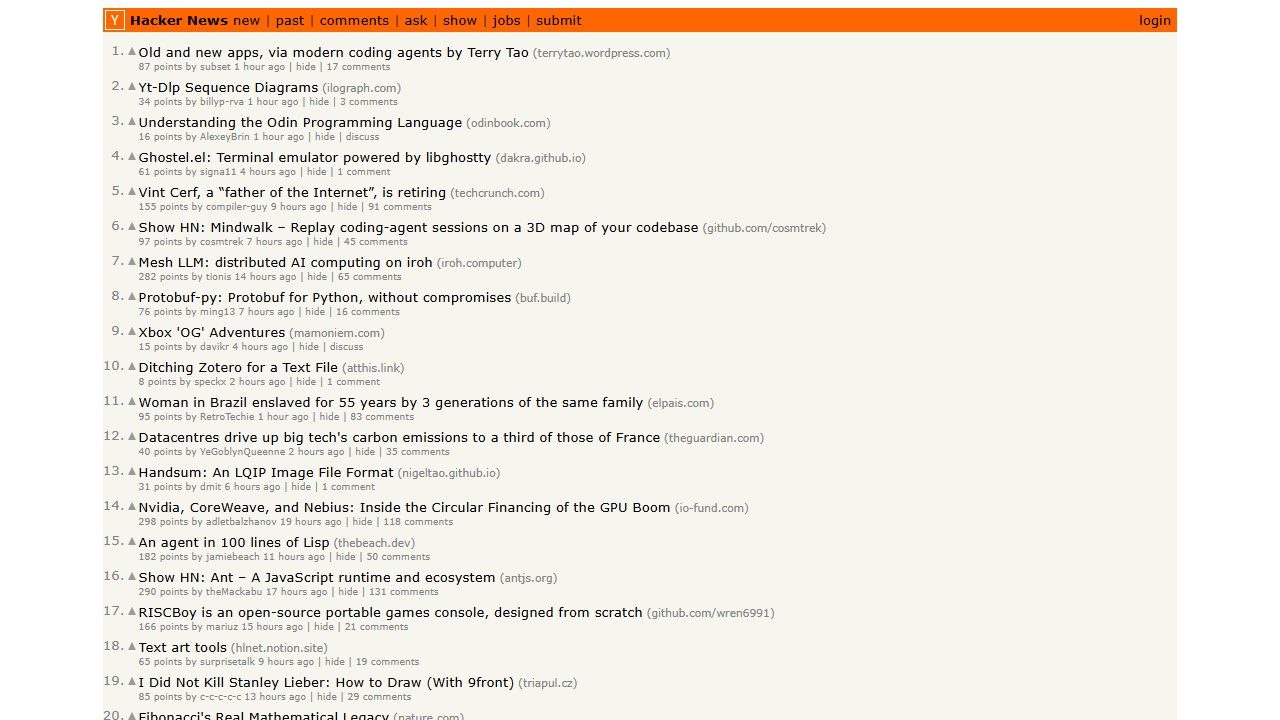

In [9]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

## Add now 2 more MCP servers - This time Javascript based, with node  
Playwright drives a real web browser, so the agent can open pages and click around. The filesystem sever reads and writes files, and we point it at a single `sandbox` folder so the agent can only touch files in there and nothign else on your machine.  


In [10]:
playwright_params = {'command' : 'npx', 'args' : ['@playwright/mcp@latest']}
async with MCPServerStdio(params = playwright_params, client_session_timeout_seconds=60) as server:
    playwright_tools = await server.list_tools()

playwright_tools

[Tool(name='browser_close', title=None, description='Close the page', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {}, 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Close browser', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execution=None),
 Tool(name='browser_resize', title=None, description='Resize the browser window', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {'width': {'type': 'number', 'description': 'Width of the browser window'}, 'height': {'type': 'number', 'description': 'Height of the browser window'}}, 'required': ['width', 'height'], 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Resize browser window', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execut

In [18]:
sandbox_path = os.path.abspath(os.path.join(os.getcwd(), "sandbox"))  # the only folder the filesystem server may touch
files_params = {"command": "npx", "args": ["-y", "@modelcontextprotocol/server-filesystem", sandbox_path]}

async with MCPServerStdio(params=files_params, client_session_timeout_seconds=60) as server:
    file_tools = await server.list_tools()

file_tools

[Tool(name='read_file', title='Read File (Deprecated)', description='Read the complete contents of a file as text. DEPRECATED: Use read_text_file instead.', inputSchema={'$schema': 'http://json-schema.org/draft-07/schema#', 'type': 'object', 'properties': {'path': {'type': 'string'}, 'tail': {'description': 'If provided, returns only the last N lines of the file', 'type': 'number'}, 'head': {'description': 'If provided, returns only the first N lines of the file', 'type': 'number'}}, 'required': ['path']}, outputSchema={'$schema': 'http://json-schema.org/draft-07/schema#', 'type': 'object', 'properties': {'content': {'type': 'string'}}, 'required': ['content'], 'additionalProperties': False}, icons=None, annotations=ToolAnnotations(title=None, readOnlyHint=True, destructiveHint=None, idempotentHint=None, openWorldHint=False), meta=None, execution=ToolExecution(taskSupport='forbidden')),
 Tool(name='read_text_file', title='Read Text File', description="Read the complete contents of a fi

### Bring on the Agent with Tools!  
Hand both servers to a single agent and give it a goal. Watch it decide on its own when to browse with playwright and when to write a file with filesystem server, then open the trace to see the tool calls it made.

In [22]:
INSTRUCTIONS = """
You browse the internet to accomplish your instructions.
Accept cookies and navigate pop-ups as needed.
If one webste isn't fruitful, try another.
Be persistent until you have sovled your assignemt,
trying different options and sites as needed.
When you need to write files, you do that inside the sandbox/ folder only.
"""

# TASK = "Find a great recipe for Banoffee Pie, then summarize it in a markdown banoffee.md"
TASK = 'Find a conference in united arab emirates. Conference to find should feature Artificial intelligence, Data Science, and Machine learning etc. target is to present my thesis. Output in markdown file name it conference.md'

async with MCPServerStdio(params = files_params, client_session_timeout_seconds=60) as mcp_server_files:
    async with MCPServerStdio(params = playwright_params, client_session_timeout_seconds=60) as mcp_server_browser:
        agent = Agent(
            name = 'investigator',
            instructions = INSTRUCTIONS,
            model = 'gpt-4o-mini',
            mcp_servers = [mcp_server_browser, mcp_server_files]
        )

        with trace('investigator'):
            result = await Runner.run(agent, TASK, max_turns = 30)
            print(result.final_output)

I found a conference that you might be interested in:

# Upcoming Conference in United Arab Emirates

### Conference Title: International Conference on Recent Advances in Medical, Medicine and Health Sciences (ICRAMMHS)

- **Date:** 10th September 2026  
- **Location:** Belgrade, Serbia (Please verify the exact location and relevance to UAE)

### About the Conference:
ICRAMMHS will bring together innovative academics and industrial experts in the field of Medical, Medicine, and Health Sciences to a common forum. All the registered papers will be published by the World Research Library and will be submitted for review for indexing by Google Scholar, etc. This Conference is sponsored by many international institutes and would include a large number of invited lectures from renowned speakers. Best paper awards will also be awarded for the contributions made during the conference.

### Registration Link:
[Register Here](https://www.allconferencealert.com/event/2071232)

The details are sav

### One more thing: a remote MCP server  
Every server so far has been local: we gave `MCPServerStdio` a command, it spawned the server as s subprocess on your machine, and they talked over stdin and stdout. Plenty of MCP servers instead run as a hosted service you reach over HTTP. You connect to one of those with `MCPServerStreamableHttp` and a URL, with nothing to spawn and nothing to install.

In [23]:
from agents.mcp import MCPServerStreamableHttp

In [28]:
question = """
In the SandboxAgents feature added to the OpenAI SDK in 2026, what is the Manifest object for? 
Be accurate. """


In [29]:
agent = Agent(name = 'Expert', instructions = "Answer the question", model ='gpt-4o-mini')

result = await Runner.run(agent, question, max_turns = 10)
print(result.final_output)

In the SandboxAgents feature added to the OpenAI SDK in 2026, the Manifest object is used to define the structure and capabilities of an agent. It includes metadata about the agent, such as its name, description, version, and the various functions it can perform. The Manifest serves as a blueprint that informs the SDK and users about what functionalities are available and how to interact with the agent, ensuring that it operates within defined parameters and adheres to specified guidelines.


In [30]:
params = {"url": "https://mcp.context7.com/mcp", "timeout": 60}

async with MCPServerStreamableHttp(name="Context7", params=params) as server:
    agent = Agent(name="Expert", instructions="Use Context7 to answer the question.", mcp_servers=[server], model="gpt-4o-mini")
    result = await Runner.run(agent, question)

print(result.final_output)

In the OpenAI SDK, specifically relating to the SandboxAgents feature added in 2026, the **Manifest object** serves as a crucial component for defining and managing the configuration of projects and their associated hosted tools.

### Key Functions of the Manifest Object:

1. **Project Configuration**: The Manifest object encapsulates various settings and permissions that dictate how tools within a project can be accessed and utilized.

2. **Hosted Tool Permissions**: It specifies the permissions for each tool that the project can leverage, ensuring that security and access control are properly managed.

3. **Structure**: The Manifest is structured to facilitate easy updates and retrievals of permissions, enhancing the overall management of project resources.

For detailed interactions and implementations, you can refer to the API documentation in the OpenAI Python SDK.


### Check out the trace

https://platform.openai.com/traces

### Now take a look at some MCP marketplaces

https://glama.ai/mcp

https://smithery.ai/